In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

import shap
from jaxsr import BasisLibrary, SymbolicRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay
import xgboost as xgb
import math





## 1. Data Cleaning and Processing

### 1.1 Data loading and format conversion

In [48]:
# Load the dataset
absorb = pd.read_csv("abs.csv")
absorb.head()

cat = pd.read_csv("cat.csv")
cat.head()

gain_70 = pd.read_csv("gain_70.csv")
gain_70.head()  

new_rows = absorb.columns[2:-3]
df = pd.DataFrame()
df["well"]=new_rows

# Converting table into long format and time into hours
absorb["Time"] = pd.to_timedelta(absorb["Time"]).dt.total_seconds()/3600
well_cols = absorb.columns[absorb.columns.str.match(r"^[A-H](?:[1-9]|1[0-2])$")]
abs_long = absorb[["Time", *well_cols]].melt(id_vars="Time", var_name="well", value_name="OD")
abs_long = abs_long.merge(cat[["well", "media_type", "function"]], on="well", how="left")

### 1.2 Blank wells check (if they drifts over time)

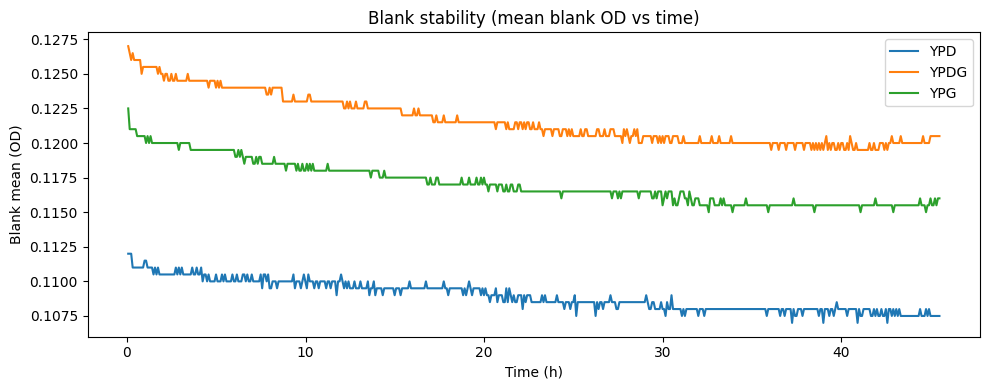

In [49]:
blank_only = abs_long[abs_long["well"].isin(abs_long[abs_long["function"].str.lower().eq("blank")]["well"].unique())].copy()

blank_curve = (blank_only
              .groupby(["media_type","Time"], as_index=False)["OD"]
              .mean()
              .rename(columns={"OD":"blank_mean"}))

# plot blank means
plt.figure(figsize=(10,4))
for mt, g in blank_curve.groupby("media_type"):
    plt.plot(g["Time"], g["blank_mean"], label=mt)
plt.xlabel("Time (h)"); plt.ylabel("Blank mean (OD)")
plt.title("Blank stability (mean blank OD vs time)")
plt.legend()
plt.tight_layout()
plt.show()



Blank stability plot

The blank wells show a small, monotonic decrease in OD over time  with no oscillations or sudden shifts. The magnitude of this drift is negligible compared to biological growth signals (from 0.12 to 1.75 in D12 and H9), indicating the plate reader measurements are stable and early OD differences primarily reflect biological activity rather than instrumental artifacts.

### 1.3 Data Standarization (Baseline Subctraction + Blank Subtraction)

Baseline subtraction is essential in cell growth modeling to remove non-biological background noise (e.g., media absorbance, instrument fluctuations) from raw measurement data. 

In [50]:
# Baseline correction for instrumental noise:
abs_long = abs_long.sort_values(["well", "Time"])
abs_long["OD_basecorr"] = abs_long["OD"] - abs_long.groupby("well")["OD"].transform("first")

# Blank subtraction 
blank_ref = (
    abs_long[abs_long["function"]=="blank"]
    .groupby(["media_type", "Time"], as_index=False)["OD"]
    .mean()
    .rename(columns={"OD": "OD_blank"})
)

abs_long = abs_long.merge(blank_ref, on=["media_type", "Time"], how="left")
abs_long["OD"] = abs_long["OD"] - abs_long["OD_blank"]



### 1.4 Abnormal growth detection

First, any well with OD below −0.01 was flagged, since negative optical density is not physically meaningful and usually indicates measurement error.

Second, detect sharp up–down oscillations in the growth curve. Real biological growth should be smooth, so sudden slope flips with large magnitude likely indicate artifacts such as bubbles, pipetting errors, or plate reader noise.

To determine what counts as “unusually large,” we used median + 6×MAD as the threshold.

MAD (Median Absolute Deviation) measures typical variability in a robust way. Unlike standard deviation, it is not distorted by extreme outliers.

This means our threshold reflects what most wells look like, and only wells that behave extremely differently from the rest of the plate are flagged.

Using 6×MAD makes the method conservative, so we avoid over-flagging normal biological variation.

Overall, this approach combines biological reasoning (growth should be smooth) with robust statistics (MAD-based threshold), making the bad-well detection reliable and defensible.

,well,min_OD,max_abs_jump,max_spike,flag_negative,flag_spike,flag_any
39,E11,0.0060,0.0660,0.0890,False,True,True
41,E2,0.0055,0.0585,0.0755,False,True,True
44,E5,0.0055,0.0530,0.0820,False,True,True
47,E9,0.0010,0.0590,0.0790,False,True,True
66,G7,-0.0035,0.0510,0.0810,False,True,True
75,H4,-0.0060,0.0520,0.0930,False,True,True
77,H6,0.0010,0.0655,0.1165,False,True,True
79,H8,0.0040,0.0460,0.0750,False,True,True


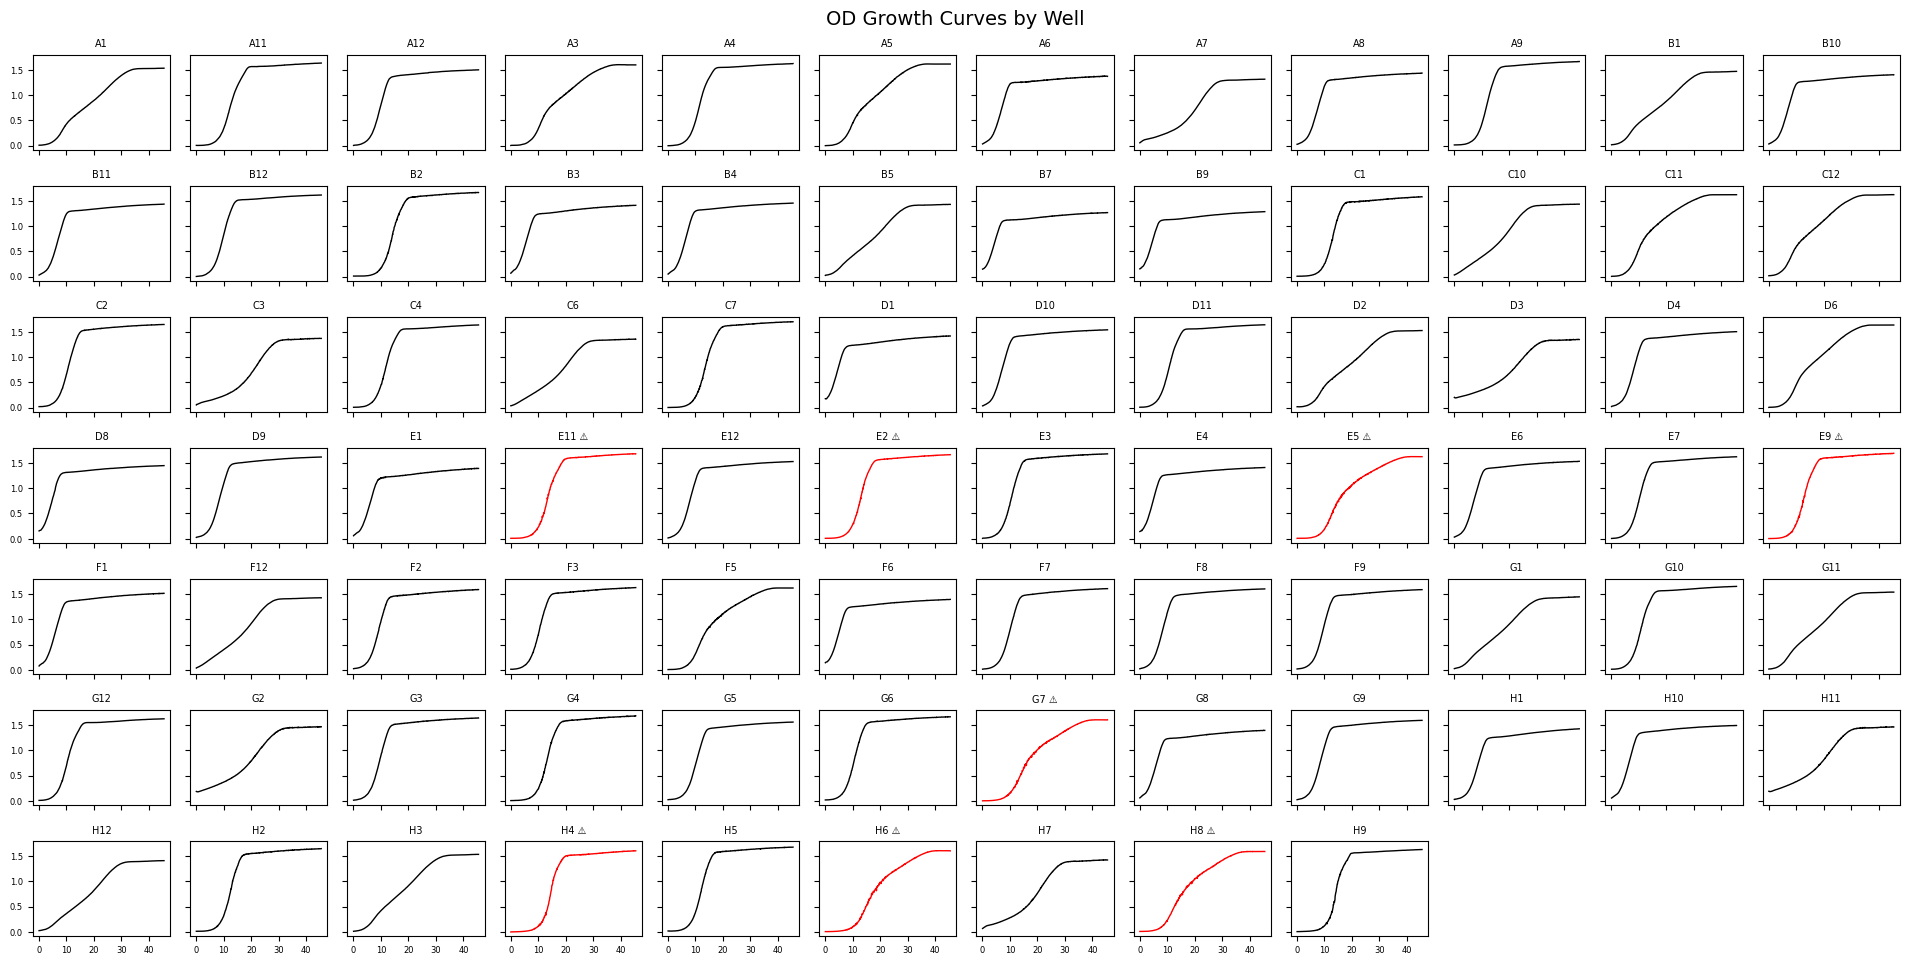

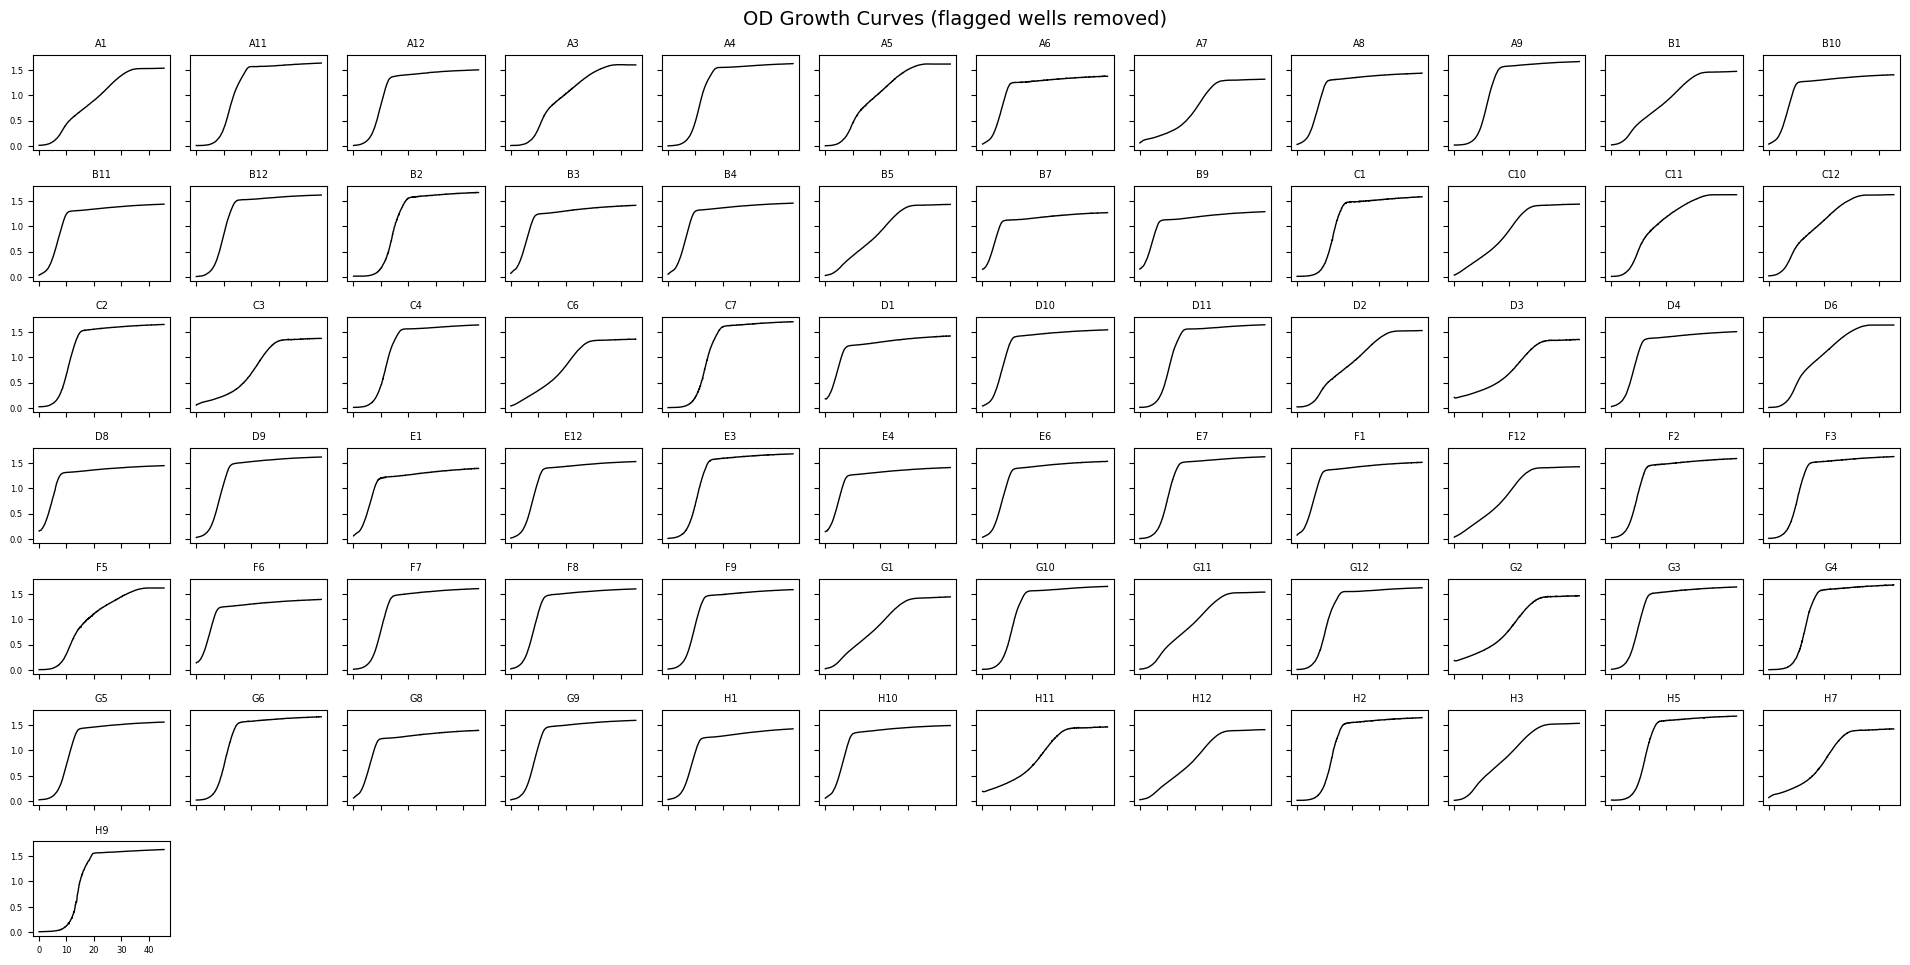

In [51]:
# Flag bad wells (negative or large jumps)
abs_long = abs_long[~abs_long["function"].isin(["blank", "standard"])].copy()

# Sort
abs_long = abs_long.sort_values(["well", "Time"]).copy()

# First difference
abs_long["dOD"] = abs_long.groupby("well")["OD"].diff()

# Spike score: look for sign flips (up then down, or down then up)
abs_long["dOD_next"] = abs_long.groupby("well")["dOD"].shift(-1)
abs_long["spike_score"] = (
    abs_long["dOD"].abs() + abs_long["dOD_next"].abs()
) * ((abs_long["dOD"] * abs_long["dOD_next"]) < 0)  # True when sign flips

bad = (abs_long.groupby("well")
       .apply(lambda g: pd.Series({
           "min_OD": g["OD"].min(),
           "max_abs_jump": g["dOD"].abs().max(),
           "max_spike": g["spike_score"].max()
       }))
       .reset_index())

# Negative OD rule
bad["flag_negative"] = bad["min_OD"] < -0.01

# Spike threshold (robust)
med = bad["max_spike"].median()
mad = np.median(np.abs(bad["max_spike"] - med))
thr_spike = med + 6*mad if mad > 0 else bad["max_spike"].quantile(0.99)

bad["flag_spike"] = bad["max_spike"] > thr_spike

# Final flagged
bad["flag_any"] = bad["flag_negative"] | bad["flag_spike"]
display(bad[bad["flag_any"]])

flagged_wells = bad.loc[bad["flag_any"], "well"]

# Keep source tables unchanged; use flagged_wells only for QC display/filtering.


# --- Plot 1: show flagged in red ---
wells = sorted(abs_long["well"].unique())
cols = 12
rows = math.ceil(len(wells) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*1.6, rows*1.4), sharex=True, sharey=True)
axes = axes.flatten()

for i, w in enumerate(wells):
    g = abs_long[abs_long["well"] == w]
    ax = axes[i]

    # choose color
    if w in flagged_wells.values:
        color = "red"
        title = f"{w} ⚠"
    else:
        color = "black"
        title = w

    ax.plot(g["Time"], g["OD"], color=color, linewidth=1)
    ax.set_title(title, fontsize=7)
    ax.tick_params(labelsize=6)

# remove unused panels
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("OD Growth Curves by Well", fontsize=14)
plt.tight_layout()
plt.show()
# Remove flagged wells only in a derived table used for downstream QC plots.
abs_long_clean = abs_long[~abs_long["well"].isin(flagged_wells)].copy()


# --- Plot 2: show all wells except flagged ---

wells2 = sorted(abs_long_clean["well"].unique())
cols = 12
rows2 = math.ceil(len(wells2) / cols)

fig, axes = plt.subplots(rows2, cols,
                         figsize=(cols*1.6, rows2*1.4),
                         sharex=True, sharey=True)
axes = axes.flatten()

for i, w in enumerate(wells2):
    g = abs_long_clean[abs_long_clean["well"] == w]
    ax = axes[i]

    ax.plot(g["Time"], g["OD"], color="black", linewidth=1)
    ax.set_title(w, fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("OD Growth Curves (flagged wells removed)", fontsize=14)
plt.tight_layout()
plt.show()





### 1.5 Data smoothing (avoid noise by bubbles / instrumental noises)

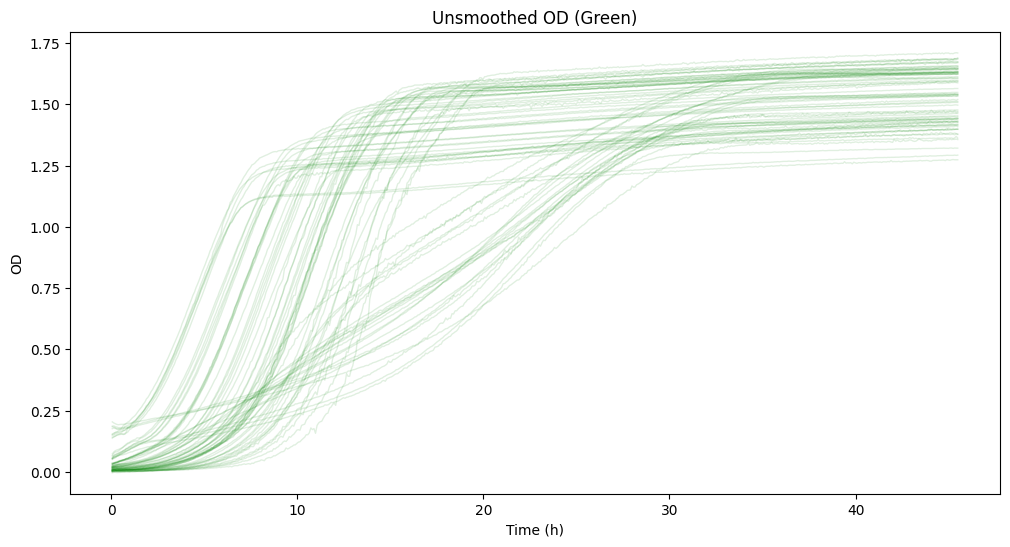

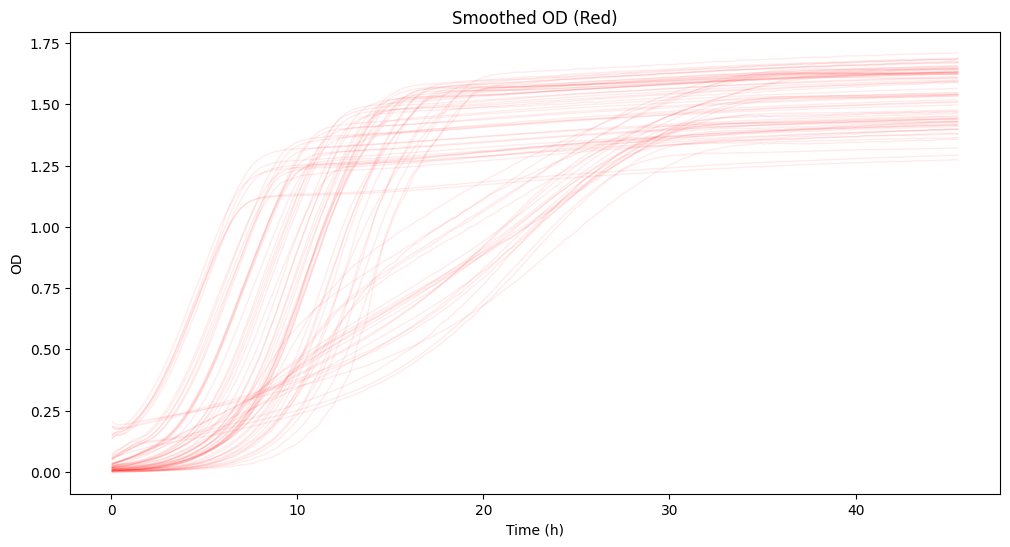

Median noise raw   : 0.00503550010003673
Median noise smooth: 0.0048146815960752945
Noise reduction %  : 4.385234824239692


In [52]:
# Smoothing (Savitzky-Golay per well)
def smooth_group(g):
    g = g.sort_values("Time").copy()
    y = g["OD"].values

    # choose valid window size automatically
    n = len(y)
    if n < 5:
        g["OD_smooth"] = y
        return g

    window = min(11, n if n % 2 == 1 else n-1)
    window = max(window, 5)  # minimum usable
    
    try:
        g["OD_smooth"] = savgol_filter(y, window_length=window, polyorder=3)
    except:
        g["OD_smooth"] = y
        
    return g


# Smooth while keeping columns
abs_long = (
    abs_long
    .sort_values(["well", "Time"])
    .groupby("well")
    .apply(smooth_group)
    .reset_index()
)
abs_long = abs_long.drop(columns=["level_1"], errors="ignore")


#Compare raw corrected vs smoothed for a quick check
plt.figure(figsize=(12, 6))
for _, g in abs_long.groupby("well"):
    plt.plot(g["Time"], g["OD"],"g-", alpha=0.12, lw=1)
plt.xlabel("Time (h)")
plt.ylabel("OD")
plt.title("Unsmoothed OD (Green)")
plt.show()

plt.figure(figsize=(12, 6))
for _, g in abs_long.groupby("well"):
    plt.plot(g["Time"], g["OD_smooth"], "r-", alpha=0.08, lw=1)
plt.xlabel("Time (h)")
plt.ylabel("OD")
plt.title("Smoothed OD (Red)")
plt.show()

# Simple numeric noise check (median std of first differences)
noise_raw = abs_long.groupby("well")["OD"].apply(lambda s: np.nanstd(np.diff(s)))
noise_smooth = abs_long.groupby("well")["OD_smooth"].apply(lambda s: np.nanstd(np.diff(s)))
print("Median noise raw   :", float(np.nanmedian(noise_raw)))
print("Median noise smooth:", float(np.nanmedian(noise_smooth)))
print("Noise reduction %  :", float(100*(1 - np.nanmedian(noise_smooth)/np.nanmedian(noise_raw))))




### 1.6 ln(OD) vs Time Analysis

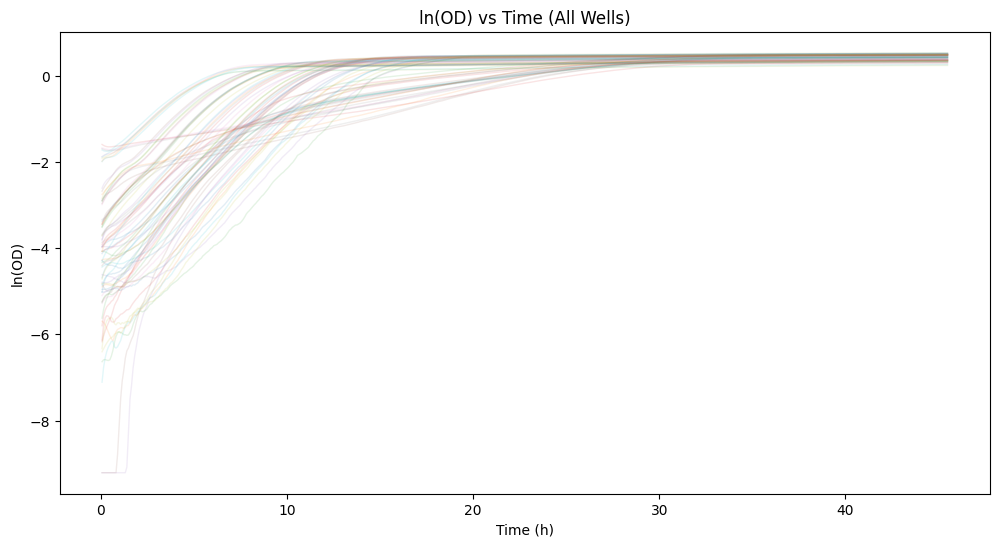

In [53]:
#plot ln(OD) vs time to check for exponential growth phases
plt.figure(figsize=(12, 6))

for _, g in abs_long.groupby("well"):
    
    g = g.sort_values("Time")
    
    # avoid log(0) or negative values
    od_clean = g["OD_smooth"].clip(lower=1e-4)
    ln_od = np.log(od_clean)
    
    plt.plot(g["Time"], ln_od, alpha=0.12, lw=1)

plt.xlabel("Time (h)")
plt.ylabel("ln(OD)")
plt.title("ln(OD) vs Time (All Wells)")
plt.show()




The ln(OD) vs time curves show a clear straight-line region during mid-growth.

A straight line on a log scale indicates exponential growth behavior.

The slope of this linear region represents the specific growth rate (μ).

Differences in when curves begin rising reflect variation in lag time across wells.

Differences in steepness reflect variation in growth rates between conditions.

After smoothing, the curves appear stable and free of irregular oscillations.

This supports reliable calculation of growth features such as μ, lag time, and early curvature from the processed data.

## 2. Feature Engineering

To transform each OD time-series into model-ready variables, I extract biologically meaningful parameters that describe the three classical growth phases (lag, exponential, and stationary). These parameters are motivated by standard sigmoidal growth models such as Gompertz, logistic, and three-phase linear models.

The features I include are:

media_type

OD_init – the initial biomass level at t = 0.

μ_max – the maximum specific growth rate, calculated as the maximum slope of ln(OD) versus time; this represents the intrinsic exponential growth constant.

lag_time (λ) – the time at which sustained positive growth begins, capturing the adaptation phase.

AUC_4h – the integrated biomass accumulation during early growth (0–4 h).

curvature_4h – the difference in slope between early windows (0–2 h vs 2–4 h), measuring acceleration into exponential phase.

OD_max – the maximum OD reached, serving as a proxy for carrying capacity.

By extracting these variables, I summarize each full growth curve into interpretable kinetic parameters, enabling downstream modeling (e.g., predicting protein expression) without directly using the entire time-series data.

### 2.1 media_type and OD_init

In [54]:
# ----------------------------
# 1) Base feature table: metadata + OD_init
# ----------------------------
df_feat = df.merge(
    cat[["well", "OD_init", "media_type", "function"]],
    on="well",
    how="left"
)[["well", "OD_init", "media_type", "function"]]

# One-hot encode media_type
df_feat = pd.get_dummies(
    df_feat,
    columns=["media_type"],
    drop_first=True   # avoids multicollinearity
)

# drop blanks and standards (they won't be in test set and have different distributions)
df_feat = df_feat[
    ~df_feat["function"].str.lower().isin(["blank", "standard"])
].copy()


### 2.2 μ_max

In [55]:
# https://www.sciencedirect.com/science/article/pii/S016816051100763X#s0050
def compute_mu_max(g, od_min=0.05, od_max=0.6, window=7):
    """
    mu_max = max slope of ln(OD_smooth) vs time using rolling linear regression.
    """
    g = g.dropna(subset=["Time", "OD_smooth"]).sort_values("Time").copy()
    g = g[g["OD_smooth"].between(od_min, od_max)]
    if len(g) < window:
        return np.nan

    ln_od = np.log(g["OD_smooth"].to_numpy())
    t = g["Time"].to_numpy()

    mu_vals = []
    for i in range(len(t) - window + 1):
        tw = t[i:i+window]
        yw = ln_od[i:i+window]
        if np.all(np.isfinite(tw)) and np.all(np.isfinite(yw)):
            mu_vals.append(np.polyfit(tw, yw, 1)[0])  # 1/h

    if len(mu_vals) == 0:
        return np.nan

    mu_vals = np.array(mu_vals)
    mu_vals = mu_vals[(mu_vals > 0) & (mu_vals < 1.5)]
    if len(mu_vals) == 0:
        return np.nan

    return float(np.max(mu_vals))

mu_df = (
    abs_long.groupby("well")
    .apply(compute_mu_max)
    .reset_index(name="mu_max")
)
df_feat = df_feat.merge(mu_df, on="well", how="left")



### 2.3 lag_time

In [56]:
def compute_lag_time(g, window=9, slope_thresh=0.002):
    g = g.dropna(subset=["Time", "OD_smooth"]).sort_values("Time")
    g = g[g["OD_smooth"] > 0].copy()
    if len(g) < 3:
        return np.nan

    dt = g["Time"].diff()
    slope = g["OD_smooth"].diff() / dt
    slope = slope.where(dt > 0, np.nan)

    slope_roll = slope.rolling(window=window, min_periods=3).mean()

    above = slope_roll > slope_thresh
    persistent = above & above.shift(1, fill_value=False)

    if not persistent.any():
        return np.nan

    return g.loc[persistent, "Time"].iloc[0]

lag_df = (
    abs_long.groupby("well")
    .apply(compute_lag_time)
    .reset_index(name="lag_time")
)
df_feat = df_feat.merge(lag_df, on="well", how="left")

### 2.4 AUC_4h

how much total growth has happened in the first 4 hours.

Captures early biomass production.
Combines growth rate and lag behavior into one number.
If a culture starts growing early and grows steadily, AUC_4h will be large.
If growth is slow or delayed, AUC_4h will be small.

In [57]:
def compute_auc_4h(g):
    g = (g.dropna(subset=["Time", "OD_smooth"])
           .sort_values("Time"))
    g = g[(g["Time"] >= 0) & (g["Time"] <= 4)]
    if len(g) < 3:
        return np.nan
    t = g["Time"].to_numpy()
    od = g["OD_smooth"].to_numpy()
    od0 = od[0]
    return np.trapezoid(od - od0, t)   # baseline-subtracted AUC

auc_df = (
    abs_long.groupby("well")
    .apply(compute_auc_4h)
    .reset_index(name="AUC_4h")
)
df_feat = df_feat.merge(auc_df, on="well", how="left")

### 2.5 curvature_4h

It measures how the growth rate is changing during the first 4 hours. (Is growth accelerating? Is it flattening?Is it transitioning out of lag phase?)

In [58]:
def compute_curvature_4h(g):
    g = (g.dropna(subset=["Time", "OD_smooth"])
           .sort_values("Time"))
    # restrict to 0–4 hr
    g = g[(g["Time"] >= 0) & (g["Time"] <= 4)]
    if len(g) < 3:
        return np.nan

    x = g["Time"].to_numpy()
    y = g["OD_smooth"].to_numpy()

    def slope_in_window(t0, t1, right_closed=True):
        if right_closed:
            w = (x >= t0) & (x <= t1)
        else:
            w = (x >= t0) & (x <  t1)
        if w.sum() < 3:
            return np.nan
        return np.polyfit(x[w], y[w], 1)[0]  # OD/hr

    m01 = slope_in_window(0, 2, right_closed=False)  # [0,2)
    m24 = slope_in_window(2, 4, right_closed=True)   # [2,4]
    if np.isfinite(m01) and np.isfinite(m24):
        return m24 - m01
    return np.nan

curv_df = (
    abs_long.groupby("well")
    .apply(compute_curvature_4h)
    .reset_index(name="curvature_4h")
)
df_feat = df_feat.merge(curv_df, on="well", how="left")

### 2.6 OD_max

In [59]:
odmax_df = (
    abs_long.groupby("well")["OD_smooth"]
    .max()
    .reset_index(name="OD_max")
)
df_feat = df_feat.merge(odmax_df, on="well", how="left")
df_merged= df_feat.copy()
df_merged.describe()


,OD_init,mu_max,lag_time,AUC_4h,curvature_4h,OD_max
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,5.218322,0.511804,0.734136,0.165233,0.023914,1.533852
std,7.234441,0.109925,0.653884,0.180144,0.028543,0.111762
min,0.078125,0.080313,0.401944,-0.001938,-0.023270,1.273832
25%,0.312500,0.482466,0.401944,0.036610,0.007269,1.437713
50%,1.250000,0.518230,0.401944,0.079984,0.013488,1.540009
75%,5.000000,0.568640,0.985278,0.234341,0.026596,1.631140
max,22.500000,0.735284,3.651944,0.634096,0.100389,1.710353


### 2.8 Compute Outcome column

We use fluorescence divided by OD as the outcome because OD reflects total biomass (how many cells grew), while fluorescence reflects total protein in the well, which increases both with more cells and with higher per-cell expression. 

Using fluorescence alone would confound growth and productivity, since faster-growing cultures would naturally produce more total fluorescence even if individual cells are not more efficient. By normalizing fluorescence by OD, we approximate protein expression per cell, which better isolates cellular productivity from simple biomass accumulation. 

Additionally, we use only the gain_70 fluorescence channel because it was identified by a PhD student in the lab as the most expressive and sensitive setting for detecting GFP signal in this system, meaning it provides the strongest dynamic range and signal-to-noise ratio for modeling protein expression.

In [60]:
# ---------- A) Wide fluorescence -> long ----------
# gain_70 wide format: Time + well columns (A1..H12)
well_cols = gain_70.columns[gain_70.columns.str.match(r"^[A-H](?:[1-9]|1[0-2])$")]

fl_long = gain_70[["Time", *well_cols]].melt(
    id_vars="Time", var_name="well", value_name="FL"
)
fl_long["Time"] = pd.to_timedelta(fl_long["Time"], errors="coerce").dt.total_seconds() / 3600

# attach metadata for blank correction
fl_long = fl_long.merge(cat[["well", "media_type", "function"]], on="well", how="left")

# ---------- B) fluorescence baseline + blank correction ----------
fl = fl_long.copy()
fl["FL"] = pd.to_numeric(fl["FL"], errors="coerce")

i0 = fl.groupby("well")["Time"].idxmin()
fl0 = fl.loc[i0, ["well", "FL"]].rename(columns={"FL": "FL_t0"})
fl = fl.merge(fl0, on="well", how="left")
fl["FL_base"] = fl["FL"] - fl["FL_t0"]

blank_ref = (
    fl[fl["function"].str.lower().eq("blank")]
    .groupby(["media_type", "Time"], as_index=False)["FL_base"]
    .mean()
    .rename(columns={"FL_base": "FL_blank"})
)

fl = fl.merge(blank_ref, on=["media_type", "Time"], how="left")
fl["FL_corr"] = fl["FL_base"] - fl["FL_blank"]

# ---------- C) align to OD end time (earlier stop between FL and OD) ----------
od = abs_long.copy()
od_col = next(c for c in ["OD_smooth", "OD_bs", "OD"] if c in od.columns)
od["Time"] = pd.to_numeric(od["Time"], errors="coerce")
od[od_col] = pd.to_numeric(od[od_col], errors="coerce")

end_times = (
    fl.groupby("well", as_index=False)["Time"].max().rename(columns={"Time": "fl_end"})
    .merge(
        od.groupby("well", as_index=False)["Time"].max().rename(columns={"Time": "od_end"}),
        on="well",
        how="inner",
    )
)
end_times["t_end"] = end_times[["fl_end", "od_end"]].min(axis=1)

# last fluorescence at/before t_end
fl_pick = fl.merge(end_times[["well", "t_end"]], on="well", how="inner")
fl_pick = fl_pick[fl_pick["Time"] <= fl_pick["t_end"]]
idx_fl = fl_pick.groupby("well")["Time"].idxmax()
fl_final = fl_pick.loc[idx_fl, ["well", "FL_corr"]].rename(columns={"FL_corr": "final_fluor_corr"})

# last OD at/before t_end
od_pick = od.merge(end_times[["well", "t_end"]], on="well", how="inner")
od_pick = od_pick[od_pick["Time"] <= od_pick["t_end"]]
idx_od = od_pick.groupby("well")["Time"].idxmax()
od_final = od_pick.loc[idx_od, ["well", od_col]].rename(columns={od_col: "final_OD"})

# ---------- D) final outcome ----------
final_df = (
    end_times[["well", "t_end"]]
    .merge(fl_final, on="well", how="left")
    .merge(od_final, on="well", how="left")
)
final_df["outcome"] = np.where(
    final_df["final_OD"] > 0,
    final_df["final_fluor_corr"] / final_df["final_OD"],
    np.nan
)


df_merged["outcome"] = np.log10(df_merged["well"].map(final_df.set_index("well")["outcome"]))
df_merged.describe()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,OD_init,mu_max,lag_time,AUC_4h,curvature_4h,OD_max,outcome
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,49.000000
mean,5.218322,0.511804,0.734136,0.165233,0.023914,1.533852,3.752398
std,7.234441,0.109925,0.653884,0.180144,0.028543,0.111762,0.434327
min,0.078125,0.080313,0.401944,-0.001938,-0.023270,1.273832,3.167307
25%,0.312500,0.482466,0.401944,0.036610,0.007269,1.437713,3.307174
50%,1.250000,0.518230,0.401944,0.079984,0.013488,1.540009,3.558090
75%,5.000000,0.568640,0.985278,0.234341,0.026596,1.631140,4.199414
max,22.500000,0.735284,3.651944,0.634096,0.100389,1.710353,4.243063


Negative corrected fluorescence values occur when the final fluorescence, after subtracting both the per-well baseline (t₀) and the row-wise media blank, falls slightly below the blank due to experimental noise, background drift, or minor overcorrection.

Biologically, this does not indicate “negative protein production”; rather, it means the expression level is indistinguishable from background and below the detection limit.

Since protein concentration and fluorescence intensity cannot be physically negative, these values do not represent meaningful biological signal.

Instead of forcing them to zero, these wells are excluded from modeling and transformations, as they reflect unreliable measurements rather than true negative expression.

Conceptually, this treats such cases as having no detectable expression while avoiding distortion of the statistical analysis.

## 3. t-SNE

Rows after cleaning: 49
High yield threshold (log): 1.4322903694576812


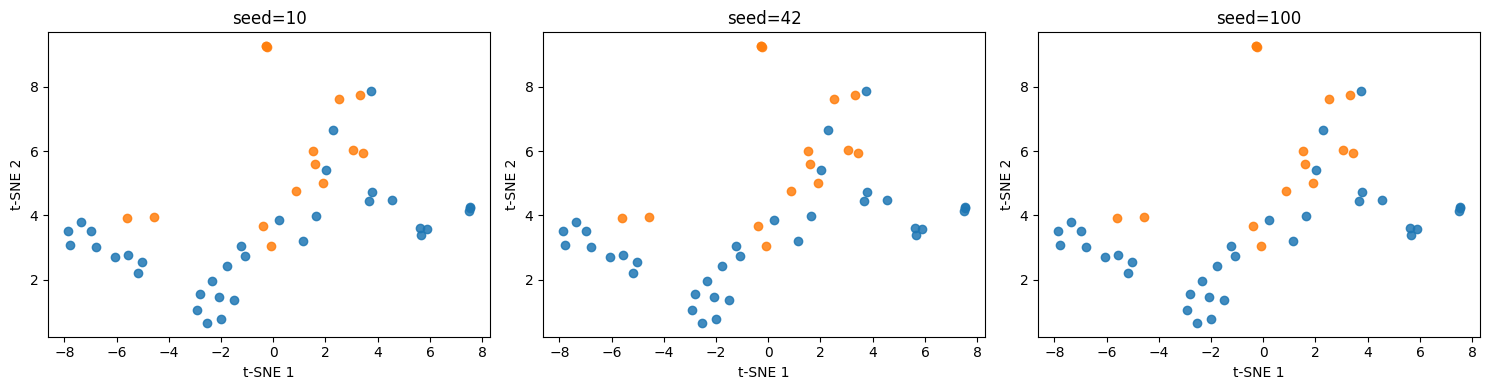

In [61]:
# ============================================================
# t-SNE visualization for your engineered growth features
# - Cleans outcome (drop outcome<=0), recompute log
# - Standardizes features
# - Runs t-SNE in 2D
# - Plots colored by yield_class and (optionally) media_type
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# ----------------------------
# 0) Inputs
# ----------------------------
df = df_merged.copy()

feature_cols = [
    "OD_init",
    "mu_max",
    "lag_time",
    "AUC_4h",
    "curvature_4h",   # or "curvature_8h" if that's what you're using
    "OD_max"
]

MEDIA_COL = "media_type" if "media_type" in df.columns else None

# ----------------------------
# 1) Clean outcome + define y
# ----------------------------
df = df[df["outcome"] > 0].copy()
df["outcome_log_clean"] = np.log(df["outcome"])

# Define high-yield class (top 30% by log outcome)
q = 0.70
thr = df["outcome_log_clean"].quantile(q)
df["yield_class"] = (df["outcome_log_clean"] >= thr).astype(int)

print("Rows after cleaning:", len(df))
print("High yield threshold (log):", thr)

# Drop missing features
df = df.dropna(subset=feature_cols).copy()

# ----------------------------
# 2) Standardize X
# ----------------------------
X = df[feature_cols].to_numpy()
Xz = StandardScaler().fit_transform(X)

# ----------------------------
# 3) Choose t-SNE params safely for small n
# ----------------------------
n = len(df)

# Perplexity rule of thumb: < n/3, typically 5–15 for n~45
perplexity = min(15, max(5, (n - 1) // 3))  # auto-ish, safe bounds
learning_rate = "auto"
# Try a few seeds and see if separation is consistent.
seeds = [10, 42, 100]
plt.figure(figsize=(15, 4))
for i, seed in enumerate(seeds, 1):
    tsne_tmp = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        random_state=seed,
        max_iter=2000
    )
    Ztmp = tsne_tmp.fit_transform(Xz)
    ax = plt.subplot(1, len(seeds), i)
    for cls in sorted(df["yield_class"].unique()):
        m = df["yield_class"] == cls
        ax.scatter(Ztmp[m, 0], Ztmp[m, 1], label=f"class {cls}", alpha=0.85)
    ax.set_title(f"seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()




The clustering structure is highly consistent across different random seeds, indicating that the embedding is stable and reflects real structure in the growth features rather than random variation.

Distinct phenotypic groupings are visible, suggesting that the wells naturally organize into growth-behavior subpopulations.

High- and low-yield classes remain partially intermixed within these clusters, meaning yield is not cleanly separable based solely on early growth features.

However, some regions show local enrichment of one class, implying that nonlinear or interaction effects may differentiate subsets of wells.

Overall, the plot supports the presence of biological signal in the features, but suggests that the growth–yield relationship is complex and not trivially linearly separable.

## 4. Modelling

In [62]:
# Target
y = df_merged["outcome"].astype(float)

# Feature columns: new engineered features
base_feats = ["OD_init", "mu_max", "lag_time", "AUC_4h", "curvature_4h", "OD_max"]

# Media one-hot columns (works regardless of how many you have)
media_feats = [c for c in df_merged.columns if c.startswith("media_type_")]

features= base_feats + media_feats
# Final X
X = df_merged[features].copy()

# Convert True/False -> 0/1 (important for many models)
X[media_feats] = X[media_feats].astype(int)

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4.1 Symbolic Regression

In [63]:
# Build basis library and fit symbolic regression model
basis = BasisLibrary(len(features), feature_names=features)
basis.add_constant()
basis.add_linear()
basis.add_polynomials(max_degree=3)
basis.add_interactions()

sr = SymbolicRegressor(basis, max_terms=10, strategy="greedy_forward",
                       information_criterion="bic")
sr.fit(X_train, y_train)

print("Discovered expression:")
print(sr.expression_)
print()
y_pred_sr = sr.predict(X_test)
r2_sr = r2_score(y_test, y_pred_sr)
mse_sr = mean_squared_error(y_test, y_pred_sr)

print(f"Symbolic Regression  R² = {r2_sr:.4f},  MSE = {mse_sr:.4f}")
print(f"  Training R²: {sr.score(X_train, y_train):.4f}")
print(f"  Test R²: {sr.score(X_test, y_test):.4f}")
print(f"  Gap: {sr.score(X_train, y_train) - sr.score(X_test, y_test):.4f}")


Discovered expression:
y = 4.194 - 0.5467*OD_max*media_type_YPDG

Symbolic Regression  R² = 0.9859,  MSE = 0.0023
  Training R²: 0.9647
  Test R²: 0.9859
  Gap: -0.0213


### 4.2 Cross validation

In [64]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

class SklearnSymbolicRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, features, max_degree=3, max_terms=10,
                 strategy="greedy_forward", information_criterion="bic"):
        self.features = features
        self.max_degree = max_degree
        self.max_terms = max_terms
        self.strategy = strategy
        self.information_criterion = information_criterion

    def fit(self, X, y):
        basis = (
            BasisLibrary(n_features=len(self.features),
                         feature_names=self.features)
            .add_constant()
            .add_linear()
            .add_polynomials(max_degree=self.max_degree)
            .add_interactions(max_order=2)
        )

        self.model_ = SymbolicRegressor(
            basis_library=basis,
            max_terms=self.max_terms,
            strategy=self.strategy,
            information_criterion=self.information_criterion
        )

        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def score(self, X, y):
        return self.model_.score(X, y)
model = SklearnSymbolicRegressor(
    features=features,
    max_degree=3,
    max_terms=10
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

print("CV R² scores:", scores)
print("Mean R²:", np.mean(scores))


CV R² scores: [0.98594838 0.96773995 0.88163869 0.95966937 0.98187243]
Mean R²: 0.9553737623665095


### 4.3 Ucertainty Quantification

Nonlinear Regression Results (95% CI):
  p0 = 4.194 ± 0.04102   (SE=0.02024)
  p1 = -0.5467 ± 0.03486   (SE=0.0172)


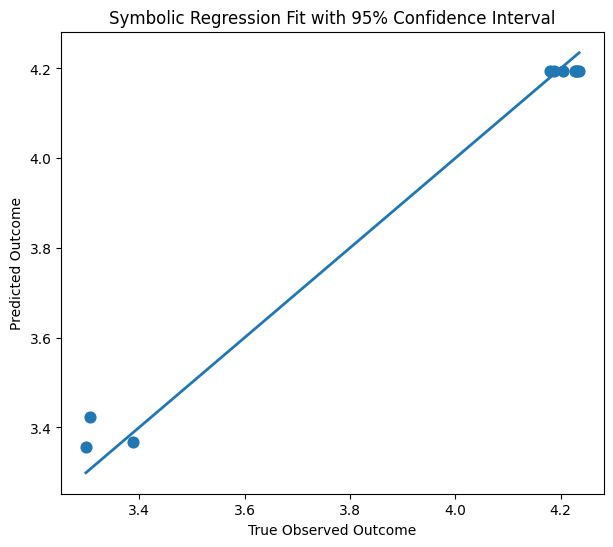

In [65]:
import re
import numpy as np
import sympy as sp
from pycse import nlinfit
import matplotlib.pyplot as plt

# --- Clean expression ---
expr_str = sr.expression_.strip()
expr_str = re.sub(r"^\s*y\s*=\s*", "", expr_str)

# --- Make sure X/y are numpy for nlinfit ---
Xtr = np.asarray(X_train, dtype=float)
ytr = np.asarray(y_train, dtype=float).ravel()
Xte = np.asarray(X_test, dtype=float)
yte = np.asarray(y_test, dtype=float).ravel()

# --- Sympy parse using your feature names ---
xs = sp.symbols(features)
xmap = {name: sym for name, sym in zip(features, xs)}

expr = sp.expand(sp.sympify(expr_str, locals=xmap))
terms = sp.Add.make_args(expr)

phis, p0 = [], []
for t in terms:
    coeff, rest = t.as_coeff_Mul()
    phis.append(sp.simplify(rest))
    p0.append(float(coeff))
p0 = np.array(p0, dtype=float)

phi_fns = [sp.lambdify(xs, phi, "numpy") for phi in phis]

def symbolic_model(X, *p):
    cols = [X[:, j] for j in range(X.shape[1])]
    yhat = np.zeros(X.shape[0], dtype=float)
    for pj, phi_fn in zip(p, phi_fns):
        yhat += pj * np.asarray(phi_fn(*cols), dtype=float)
    return yhat

# --- nlinfit with uncertainty (like your screenshot) ---
p, pint, se = nlinfit(symbolic_model, Xtr, ytr, p0, alpha=0.05)

print("Nonlinear Regression Results (95% CI):")
for j in range(len(p)):
    half_width = (pint[j, 1] - pint[j, 0]) / 2
    print(f"  p{j} = {p[j]:.4g} ± {half_width:.4g}   (SE={se[j]:.4g})")

# --- Plot predicted vs true (multi-feature equivalent of his curve plot) ---
y_pred = symbolic_model(Xte, *p)

plt.figure(figsize=(7,6))
plt.scatter(yte, y_pred, s=60, zorder=5)
mn = min(yte.min(), y_pred.min())
mx = max(yte.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], linewidth=2)
plt.xlabel("True Observed Outcome")
plt.ylabel("Predicted Outcome")
plt.title("Symbolic Regression Fit with 95% Confidence Interval")
plt.show()



p0 = average outcome for the reference media

p1 = how much the outcome changes if switch to YPDG media

The symbolic regression model identifies media type as the primary driver of the response variable.

The data show a clear two-level separation, indicating a strong shift between media conditions.

The estimated media effect (~0.55 units) is much larger than the experimental noise (~0.08), demonstrating a strong signal relative to variability.

The parameter confidence intervals are narrow, indicating precise and stable coefficient estimates.

Predicted values align closely with observed values, showing good model fit.

Overall, the model is simple, interpretable, and statistically well-supported by both the visual and quantitative results.